In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [2]:
df= pd.read_csv(r"C:\Users\Earlycode\Documents\abraham_class\construction_project_dataset.csv")
df.head(10)

,timestamp,temperature,humidity,vibration_level,material_usage,machinery_status,worker_count,energy_consumption,task_progress,cost_deviation,time_deviation,safety_incidents,equipment_utilization_rate,material_shortage_alert,risk_score,simulation_deviation,update_frequency,optimization_suggestion,performance_score
0,2023-01-01 00:00:00,24.363503,70.834195,29.038952,162.290510,0,10,394.617852,0.025050,2707.711346,-4.645563,2,84.481661,0,23.181975,0.768037,10,Optimize Material Usage,Excellent
1,2023-01-01 00:01:00,38.767858,49.671023,26.348582,627.127074,1,16,334.086917,0.062199,1866.881543,-0.673013,0,85.115701,0,64.242931,6.958721,15,Optimize Material Usage,Excellent
2,2023-01-01 00:02:00,33.299849,31.727937,17.551847,818.981866,0,17,70.030254,0.141820,-2913.483082,-5.667880,0,82.006109,0,97.199452,8.980785,5,Reallocate Workers,Excellent
3,2023-01-01 00:03:00,29.966462,64.198507,24.660633,788.025785,1,19,275.610928,0.169591,-2778.924736,-8.373158,0,93.410108,1,58.238809,3.295682,5,Reallocate Workers,Excellent
4,2023-01-01 00:04:00,18.900466,45.120688,18.254832,853.656587,0,32,377.220779,0.185736,-2332.484349,-3.455996,0,52.694279,0,19.748945,0.223819,15,Optimize Material Usage,Excellent
5,2023-01-01 00:05:00,18.899863,55.677649,32.896567,981.512280,0,30,264.714124,0.215137,-2623.835150,9.123024,0,74.058873,0,29.942435,7.182473,10,Adjust Schedule,Excellent
6,2023-01-01 00:06:00,16.452090,26.435917,41.751483,996.237095,1,9,323.033223,0.249667,-4824.345237,-3.059610,0,75.844847,0,70.291889,4.997616,5,Adjust Schedule,Excellent
7,2023-01-01 00:07:00,36.654404,57.895039,39.344722,469.421066,1,24,443.451396,0.327201,62.097874,-5.256213,0,68.714102,1,75.295893,1.433382,15,Adjust Schedule,Excellent
8,2023-01-01 00:08:00,30.027875,42.413029,17.034621,551.885550,1,48,153.687449,0.367913,4067.754147,-6.038472,0,87.138289,0,53.555563,2.513262,5,Optimize Material Usage,Excellent
9,2023-01-01 00:09:00,32.701814,40.051385,25.470975,548.364800,0,49,381.596477,0.449187,217.852045,-4.790251,0,94.436397,0,84.256717,9.715455,5,Adjust Schedule,Excellent


In [3]:
x = df.iloc[:, [5,6,7]]
x

,machinery_status,worker_count,energy_consumption
0,0,10,394.617852
1,1,16,334.086917
2,0,17,70.030254
3,1,19,275.610928
4,0,32,377.220779
...,...,...,...
49995,1,42,429.191161
49996,0,22,392.585602
49997,0,38,174.634029
49998,0,6,240.744808


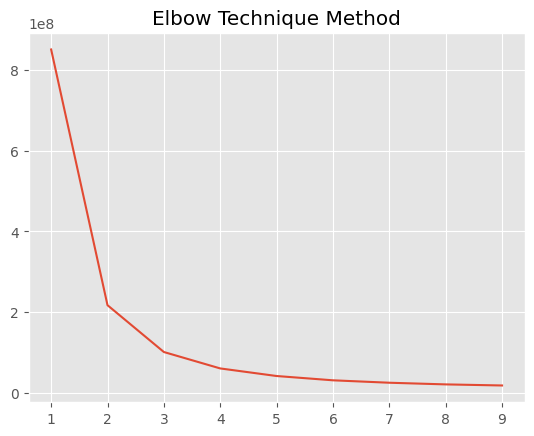

In [4]:
wcss = []
for i in range(1, 10):
    km = KMeans(n_clusters= i)
    km.fit(x)
    wcss.append(km.inertia_)
    
plt.style.use("ggplot")
plt.plot(range(1, 10), wcss)
plt.title("Elbow Technique Method")
plt.show()

In [5]:
km = KMeans(n_clusters= 2)
km.fit(x)
y_pred = km.predict(x)

In [6]:
df['Cluster'] = y_pred
df.head()

,timestamp,temperature,humidity,vibration_level,material_usage,machinery_status,worker_count,energy_consumption,task_progress,cost_deviation,time_deviation,safety_incidents,equipment_utilization_rate,material_shortage_alert,risk_score,simulation_deviation,update_frequency,optimization_suggestion,performance_score,Cluster
0,2023-01-01 00:00:00,24.363503,70.834195,29.038952,162.290510,0,10,394.617852,0.025050,2707.711346,-4.645563,2,84.481661,0,23.181975,0.768037,10,Optimize Material Usage,Excellent,0
1,2023-01-01 00:01:00,38.767858,49.671023,26.348582,627.127074,1,16,334.086917,0.062199,1866.881543,-0.673013,0,85.115701,0,64.242931,6.958721,15,Optimize Material Usage,Excellent,0
2,2023-01-01 00:02:00,33.299849,31.727937,17.551847,818.981866,0,17,70.030254,0.141820,-2913.483082,-5.667880,0,82.006109,0,97.199452,8.980785,5,Reallocate Workers,Excellent,1
3,2023-01-01 00:03:00,29.966462,64.198507,24.660633,788.025785,1,19,275.610928,0.169591,-2778.924736,-8.373158,0,93.410108,1,58.238809,3.295682,5,Reallocate Workers,Excellent,1
4,2023-01-01 00:04:00,18.900466,45.120688,18.254832,853.656587,0,32,377.220779,0.185736,-2332.484349,-3.455996,0,52.694279,0,19.748945,0.223819,15,Optimize Material Usage,Excellent,0


In [7]:
df[df["Cluster"] ==0]

,timestamp,temperature,humidity,vibration_level,material_usage,machinery_status,worker_count,energy_consumption,task_progress,cost_deviation,time_deviation,safety_incidents,equipment_utilization_rate,material_shortage_alert,risk_score,simulation_deviation,update_frequency,optimization_suggestion,performance_score,Cluster
0,2023-01-01 00:00:00,24.363503,70.834195,29.038952,162.290510,0,10,394.617852,0.025050,2707.711346,-4.645563,2,84.481661,0,23.181975,0.768037,10,Optimize Material Usage,Excellent,0
1,2023-01-01 00:01:00,38.767858,49.671023,26.348582,627.127074,1,16,334.086917,0.062199,1866.881543,-0.673013,0,85.115701,0,64.242931,6.958721,15,Optimize Material Usage,Excellent,0
4,2023-01-01 00:04:00,18.900466,45.120688,18.254832,853.656587,0,32,377.220779,0.185736,-2332.484349,-3.455996,0,52.694279,0,19.748945,0.223819,15,Optimize Material Usage,Excellent,0
6,2023-01-01 00:06:00,16.452090,26.435917,41.751483,996.237095,1,9,323.033223,0.249667,-4824.345237,-3.059610,0,75.844847,0,70.291889,4.997616,5,Adjust Schedule,Excellent,0
7,2023-01-01 00:07:00,36.654404,57.895039,39.344722,469.421066,1,24,443.451396,0.327201,62.097874,-5.256213,0,68.714102,1,75.295893,1.433382,15,Adjust Schedule,Excellent,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49991,2023-02-04 17:11:00,24.983072,27.479816,8.716229,855.662241,1,26,425.275235,100.000000,-865.627450,0.053953,0,55.677226,0,84.165388,4.684614,10,Adjust Schedule,Excellent,0
49994,2023-02-04 17:14:00,25.698943,70.635185,33.877579,141.051874,1,24,281.102831,100.000000,902.010772,-6.075474,0,85.850676,0,81.400021,0.558662,5,Increase Machinery,Excellent,0
49995,2023-02-04 17:15:00,30.561130,67.538290,11.486511,659.934969,1,42,429.191161,100.000000,735.865742,0.032939,0,78.710969,1,44.154503,0.125827,15,Increase Machinery,Excellent,0
49996,2023-02-04 17:16:00,20.654839,66.755174,4.483828,666.298453,0,22,392.585602,100.000000,2217.119886,-2.517683,0,52.612716,1,88.103771,5.516662,10,Reallocate Workers,Excellent,0


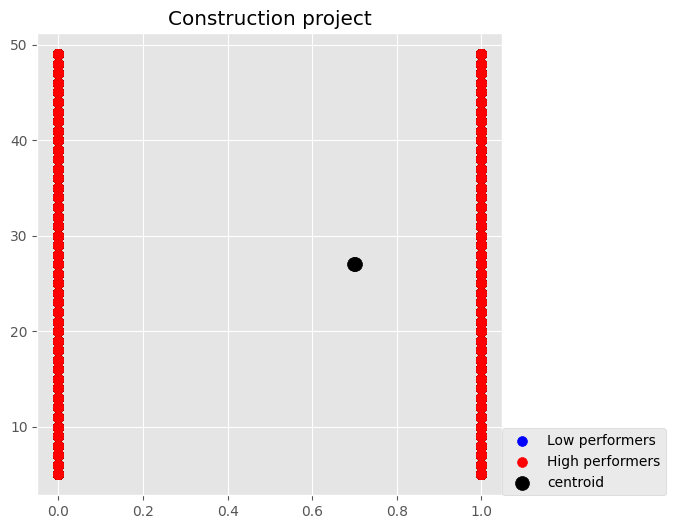

In [8]:
X = x.to_numpy()
plt.style.use("ggplot")
plt.figure(figsize=(6, 6))
plt.scatter(X[y_pred == 0, 0], X[y_pred == 0, 1], s = 50, c = "blue", label = "Low performers")
plt.scatter(X[y_pred == 1, 0],  X[y_pred == 1, 1], s = 50, c = "red", label = "High performers")
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:,1], s = 100, c = "black", label = "centroid")
plt.title("Construction project")
plt.legend(loc = [1, 0])
plt.show()

In [10]:
import streamlit as st
import joblib

In [13]:
st.title("📝 Text Classification App")

# Load model and vectorizer separately using st.cache_resource
@st.cache_resource
def load_assets():
    model = joblib.load("model.joblib")
    vectorizer = joblib.load("vectorizer.joblib")
    return model, vectorizer


user_text = st.text_area("Enter text to classify:", "")

if st.button("Classify Text"):
    if user_text.strip():
        # Transform the input text to numeric features first
        text_vectorized = vectorizer.transform([user_text])
        
        # Predict class and probabilities
        prediction = model.predict(text_vectorized)
        
        st.subheader("Result")
        st.write(f"**Predicted Category:** {prediction[0]}")
        
        if hasattr(model, "predict_proba"):
            probabilities = model.predict_proba(text_vectorized)
            confidence = max(probabilities[0]) * 100
            st.write(f"**Confidence:** {confidence:.2f}%")
    else:
        st.warning("Please enter some text before submitting.")

2026-08-29 16:43:36.831 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-29 16:43:36.831 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-29 16:43:36.831 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-29 16:43:36.831 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-29 16:43:36.837 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-29 16:43:36.839 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-29 16:43:36.839 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-29 16:43:36.839 Session state does not function when running a script without `streamlit run`
2026-08-29 16:43